<a href="https://colab.research.google.com/github/NauaneLopes/Citologia_Oral/blob/main/Modelos_%C3%81rvores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree

In [6]:
# carregar dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('/content/drive/MyDrive/RESULTADOS/EDA/features/df_new.csv')
df.columns

Index(['subset', 'classe', 'nome_imagem', 'relacao_sinal_fundo_R',
       'intensidade_sinal_G', 'relacao_sinal_fundo_G', 'intensidade_sinal_B',
       'relacao_sinal_fundo_B', 'dif_int_sinal_G_B', 'indice_sinal_R_G',
       'indice_sinal_R_B', 'dif_textura_RG', 'dif_textura_RB',
       'indice_textura_RG', 'indice_textura_RB', 'area', 'circularidade',
       'elongacao', 'compacidade', 'bbox_ratio', 'centroide_x', 'centroide_y',
       'R_media', 'R_desvio', 'R_min', 'G_media', 'G_min', 'B_media', 'B_min'],
      dtype='object')

In [8]:
# Dividir datasets
train = df[df['subset'] == 'train']
val = df[df['subset'] == 'val']
test = df[df['subset'] == 'test']
print(train.shape, val.shape, test.shape)


(22387, 29) (4052, 29) (4586, 29)


In [9]:
X_train = train.drop(['nome_imagem', 'subset', 'classe'], axis=1)
y_train = train['classe']

X_val = val.drop(['nome_imagem', 'subset', 'classe'], axis=1)
y_val = val['classe']

X_test = test.drop(['nome_imagem', 'subset', 'classe'], axis=1)
y_test = test['classe']

In [10]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(22387, 26) (22387,)
(4052, 26) (4052,)
(4586, 26) (4586,)


In [11]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [12]:
tree_model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [13]:
# fazer validação escondida
y_pred_val = tree_model.predict(X_val)
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

    abnormal       0.93      0.93      0.93      3012
      normal       0.80      0.81      0.80      1040

    accuracy                           0.90      4052
   macro avg       0.87      0.87      0.87      4052
weighted avg       0.90      0.90      0.90      4052



In [14]:
# Fazer classificação
y_pred_test = tree_model.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

    abnormal       0.95      0.94      0.94      3340
      normal       0.83      0.86      0.85      1246

    accuracy                           0.91      4586
   macro avg       0.89      0.90      0.89      4586
weighted avg       0.92      0.91      0.92      4586



[Text(0.4534749522868471, 0.9864864864864865, 'x[2] <= 0.618\ngini = 0.392\nsamples = 22387\nvalue = [16387.0, 6000.0]'),
 Text(0.17553417992019152, 0.9594594594594594, 'x[9] <= -2.185\ngini = 0.222\nsamples = 16341\nvalue = [14261, 2080]'),
 Text(0.3145045661035193, 0.972972972972973, 'True  '),
 Text(0.034220039519938426, 0.9324324324324325, 'x[23] <= 13.5\ngini = 0.474\nsamples = 1146\nvalue = [443.0, 703.0]'),
 Text(0.01618283654258363, 0.9054054054054054, 'x[23] <= 6.5\ngini = 0.272\nsamples = 401\nvalue = [336, 65]'),
 Text(0.009140231975259162, 0.8783783783783784, 'x[2] <= 0.557\ngini = 0.1\nsamples = 283\nvalue = [268, 15]'),
 Text(0.006093487983506108, 0.8513513513513513, 'x[12] <= 1348.0\ngini = 0.082\nsamples = 279\nvalue = [267.0, 12.0]'),
 Text(0.003062695530976892, 0.8243243243243243, 'x[12] <= 1302.0\ngini = 0.375\nsamples = 12\nvalue = [9, 3]'),
 Text(0.0020417970206512617, 0.7972972972972973, 'x[14] <= 1.169\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.0010208

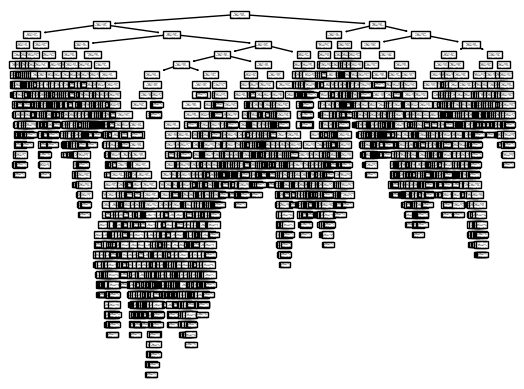

In [15]:
from sklearn import tree
import graphviz
tree.plot_tree(tree_model)


In [ ]:
tree_model.feature_importances_

array([0.01363328, 0.0024602 , 0.08094147, 0.00279477, 0.0263959 ,
       0.00853322, 0.00730744, 0.02081829, 0.04841602, 0.03052063,
       0.05912209, 0.01881355, 0.01472976, 0.00683768, 0.00939108,
       0.01678206, 0.00964836, 0.01569909, 0.01138065, 0.01404735,
       0.01999876, 0.00675411, 0.0445676 , 0.05812733, 0.00639518,
       0.08312892, 0.00890432, 0.0087387 , 0.00666107, 0.00536537,
       0.00759753, 0.3254882 ])

In [ ]:
tree_model_3 = DecisionTreeClassifier(criterion = 'entropy', ccp_alpha = 0.10)
tree_model_3.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.1, criterion='entropy')

In [ ]:
# fazer validação escondida
y_pred_val = tree_model.predict(X_val)
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

    abnormal       0.93      0.93      0.93      3012
      normal       0.81      0.80      0.80      1040

    accuracy                           0.90      4052
   macro avg       0.87      0.87      0.87      4052
weighted avg       0.90      0.90      0.90      4052



In [ ]:
# Fazer predição
y_pred_test = tree_model.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

    abnormal       0.94      0.94      0.94      3340
      normal       0.83      0.84      0.84      1246

    accuracy                           0.91      4586
   macro avg       0.89      0.89      0.89      4586
weighted avg       0.91      0.91      0.91      4586



# Melhoras no Decision Tree

In [16]:
!pip install imbalanced-learn

In [17]:
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
import plotly.graph_objs as go
import plotly.figure_factory as ff
import numpy as np

# === 1. Encoding antes do SMOTE ===
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)
class_names = list(label_encoder.classes_)

# === 2. Aplicar SMOTE apenas no treino ===
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_encoded)

# === 3. Treinar o modelo ===
tree_model_smote = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=2,
    ccp_alpha=0.01
)
tree_model_smote.fit(X_train_resampled, y_train_resampled)


DecisionTreeClassifier(ccp_alpha=0.01, criterion='entropy', max_depth=15,
                       min_samples_leaf=2)

In [24]:
# === 4. Validação escondida (X_val) ===
y_pred_val = tree_model_smote.predict(X_val)
y_pred_proba_val = tree_model_smote.predict_proba(X_val)[:, 1]

print("\n=== Relatório da Validação (Validação escondida) ===")
print(classification_report(y_val_encoded, y_pred_val))

# === 5. Teste Final (X_test) ===
y_pred_test = tree_model_smote.predict(X_test)
y_pred_proba_test = tree_model_smote.predict_proba(X_test)[:, 1]

print("\n=== Relatório Final (Teste) ===")
print(classification_report(y_test_encoded, y_pred_test))

# === 6. Matriz de Confusão ===
cm = confusion_matrix(y_test_encoded, y_pred_test)
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True,
)
fig_cm.update_layout(title='Matriz de Confusão (Teste)', xaxis_title='Previsto', yaxis_title='Real', width=400, height=400) # corrected fig_size to width and height
fig_cm.show()

# === 7. Curva ROC (Teste) ===
fpr, tpr, _ = roc_curve(y_test_encoded, y_pred_proba_test)
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC (Teste)', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo', width=600, height=400) # corrected figsize to width and height
fig_roc.show()


=== Relatório da Validação (Validação escondida) ===
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      3012
           1       0.71      0.85      0.77      1040

    accuracy                           0.87      4052
   macro avg       0.83      0.86      0.84      4052
weighted avg       0.88      0.87      0.88      4052


=== Relatório Final (Teste) ===
              precision    recall  f1-score   support

           0       0.96      0.89      0.93      3340
           1       0.76      0.89      0.82      1246

    accuracy                           0.89      4586
   macro avg       0.86      0.89      0.87      4586
weighted avg       0.90      0.89      0.90      4586



In [28]:
# Calcular feature importance para Decision tree ordem crescente
feature_importances = tree_model_smote.feature_importances_
sorted_indices = np.argsort(feature_importances)
sorted_feature_importances = feature_importances[sorted_indices]
sorted_column_names = X_train.columns[sorted_indices]
# Filtrar as 5 mais importantes
top_5_indices = sorted_indices[-5:]
top_5_feature_importances = sorted_feature_importances[-5:]
top_5_column_names = sorted_column_names[-5:]

# Plotar por meio da biblioteca plotly ordem de maior importancia
import plotly.express as px
fig = px.bar(x=top_5_feature_importances, y=top_5_column_names, orientation='h',
             labels={'x': 'Importance', 'y': 'Feature'}, width=500, height=400)
fig.update_layout(title='Importância das Features')
fig.show()

# Random Forest

In [26]:
# Random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       random_state=42)

In [27]:
# fazer validação
y_pred_val = rf_model.predict(X_val)
print(classification_report(y_val, y_pred_val))
# fazer predição
y_pred_test = rf_model.predict(X_test)
print("\n=== Relatório Final (Teste) ===")
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

    abnormal       0.94      0.98      0.96      3012
      normal       0.92      0.81      0.86      1040

    accuracy                           0.93      4052
   macro avg       0.93      0.89      0.91      4052
weighted avg       0.93      0.93      0.93      4052


=== Relatório Final (Teste) ===
              precision    recall  f1-score   support

    abnormal       0.96      0.98      0.97      3340
      normal       0.95      0.88      0.91      1246

    accuracy                           0.95      4586
   macro avg       0.95      0.93      0.94      4586
weighted avg       0.95      0.95      0.95      4586



In [30]:
import plotly.graph_objs as go
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import numpy as np

# === Previsões ===
y_pred_test = rf_model.predict(X_test)
y_pred_proba_test = rf_model.predict_proba(X_test)[:, 1]  # Probabilidade da classe positiva (classe 1)

# === Encoding das classes ===
label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)
y_pred_test_encoded = label_encoder.transform(y_pred_test)
class_names = list(label_encoder.classes_)

# === Matriz de Confusão ===
cm = confusion_matrix(y_test_encoded, y_pred_test_encoded)
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig_cm.update_layout(title='Matriz de Confusão (Teste)', xaxis_title='Previsto', yaxis_title='Real', width = 500, height = 400)
fig_cm.show()

# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test_encoded, y_pred_proba_test)
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC (Teste)', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo', width = 500, height = 400)
fig_roc.show()


In [31]:
# Calcular feature importance para RandomForest ordem crescente
feature_importances = rf_model.feature_importances_
sorted_indices = np.argsort(feature_importances)
sorted_feature_importances = feature_importances[sorted_indices]
sorted_column_names = X_train.columns[sorted_indices]
# Filtrar as 5 mais importantes
top_5_indices = sorted_indices[-20:]
top_5_feature_importances = sorted_feature_importances[-20:]
top_5_column_names = sorted_column_names[-20:]

# Plotar por meio da biblioteca plotly ordem de maior importancia
import plotly.express as px
fig = px.bar(x=top_5_feature_importances, y=top_5_column_names, orientation='h',
             labels={'x': 'Importance', 'y': 'Feature'}, width=500, height=400)
fig.update_layout(title='Importância das Features')
fig.show()

# XGBOOST

In [32]:
from sklearn.preprocessing import LabelEncoder

# === 1. Codificar os rótulos ===
le = LabelEncoder()
y_train_bal_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
y_val_enc = le.transform(y_val)

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import plotly.graph_objs as go
import plotly.figure_factory as ff
import numpy as np
from xgboost import XGBClassifier
# from xgboost.callback import EarlyStopping # Removing EarlyStopping import

# === 1. Encoding das classes ===
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
class_names = list(le.classes_)

# === 2. Ajustar o XGBoost ===
xgb = XGBClassifier(
    objective='binary:logistic',  # Se for binário
    eval_metric='logloss',
    scale_pos_weight=(np.bincount(y_train_enc)[0] / np.bincount(y_train_enc)[1]),  # Peso inverso das classes
    learning_rate=0.1,
    max_depth=6,
    n_estimators=200,
    use_label_encoder=False,
    random_state=42
)

# === 3. Treinar o modelo sem Early Stopping ===
xgb.fit(
    X_train, y_train_enc,
    eval_set=[(X_val, y_val_enc)],
    # callbacks=[early_stopping] # Removing callbacks argument
)

# === 4. Avaliação - Validação ===
print("\nAvaliação no Conjunto de Validação:")
y_pred_val = xgb.predict(X_val)
print(classification_report(y_val_enc, y_pred_val, target_names=class_names))

# === 5. Avaliação - Teste ===
print("\nAvaliação no Conjunto de Teste:")
y_pred_test = xgb.predict(X_test)
print(classification_report(y_test_enc, y_pred_test, target_names=class_names))

# === 6. Matriz de Confusão ===
cm = confusion_matrix(y_test_enc, y_pred_test)
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig_cm.update_layout(title='Matriz de Confusão (Teste)', xaxis_title='Previsto', yaxis_title='Real', width=500, height=400)
fig_cm.show()

# === 7. Curva ROC ===
y_proba_test = xgb.predict_proba(X_test)[:, 1]  # Prob da classe positiva
fpr, tpr, _ = roc_curve(y_test_enc, y_proba_test)
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC (Teste)', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo', width = 500, height = 400)
fig_roc.show()

# === 8. Precision-Recall Curve (Opcional) ===
precision, recall, _ = precision_recall_curve(y_test_enc, y_proba_test)
fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name='Curva Precision-Recall'))
fig_pr.update_layout(title='Curva de Precision-Recall', xaxis_title='Recall', yaxis_title='Precisão', width = 500, height = 400)
fig_pr.show()

# === Gráfico de LogLoss (Erro de Validação por Iteração) ===
logloss_val = xgb.evals_result_['validation_0']['logloss']

fig_loss_val = go.Figure()
fig_loss_val.add_trace(go.Scatter(
    y=logloss_val,
    mode='lines+markers',
    name='Validation LogLoss'
))

fig_loss_val.update_layout(
    title='Erro de Validação (LogLoss) por Iteração - XGBoost',
    xaxis_title='Número de Iterações (Árvores)',
    yaxis_title='LogLoss',
    width = 500,
    height = 400
)

fig_loss_val.show()


[0]	validation_0-logloss:0.62984
[1]	validation_0-logloss:0.57698
[2]	validation_0-logloss:0.53299
[3]	validation_0-logloss:0.49493
[4]	validation_0-logloss:0.46237
[5]	validation_0-logloss:0.43491
[6]	validation_0-logloss:0.41127
[7]	validation_0-logloss:0.38984
[8]	validation_0-logloss:0.37137
[9]	validation_0-logloss:0.35560
[10]	validation_0-logloss:0.34162
[11]	validation_0-logloss:0.32913
[12]	validation_0-logloss:0.31784
[13]	validation_0-logloss:0.30789
[14]	validation_0-logloss:0.29923
[15]	validation_0-logloss:0.29138
[16]	validation_0-logloss:0.28402
[17]	validation_0-logloss:0.27768
[18]	validation_0-logloss:0.27199
[19]	validation_0-logloss:0.26686
[20]	validation_0-logloss:0.26203
[21]	validation_0-logloss:0.25774
[22]	validation_0-logloss:0.25410
[23]	validation_0-logloss:0.25133
[24]	validation_0-logloss:0.24887
[25]	validation_0-logloss:0.24603
[26]	validation_0-logloss:0.24357
[27]	validation_0-logloss:0.24160
[28]	validation_0-logloss:0.23969
[29]	validation_0-loglos

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[14:50:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




[47]	validation_0-logloss:0.22160
[48]	validation_0-logloss:0.22099
[49]	validation_0-logloss:0.22082
[50]	validation_0-logloss:0.22065
[51]	validation_0-logloss:0.22001
[52]	validation_0-logloss:0.21991
[53]	validation_0-logloss:0.21907
[54]	validation_0-logloss:0.21874
[55]	validation_0-logloss:0.21863
[56]	validation_0-logloss:0.21856
[57]	validation_0-logloss:0.21821
[58]	validation_0-logloss:0.21808
[59]	validation_0-logloss:0.21731
[60]	validation_0-logloss:0.21685
[61]	validation_0-logloss:0.21681
[62]	validation_0-logloss:0.21628
[63]	validation_0-logloss:0.21601
[64]	validation_0-logloss:0.21555
[65]	validation_0-logloss:0.21508
[66]	validation_0-logloss:0.21507
[67]	validation_0-logloss:0.21466
[68]	validation_0-logloss:0.21472
[69]	validation_0-logloss:0.21432
[70]	validation_0-logloss:0.21413
[71]	validation_0-logloss:0.21392
[72]	validation_0-logloss:0.21384
[73]	validation_0-logloss:0.21382
[74]	validation_0-logloss:0.21359
[75]	validation_0-logloss:0.21299
[76]	validatio

# Gradient boosting


 [Validação] Melhor threshold para F1: 0.821

=== Relatório da Validação com Threshold Otimizado ===
              precision    recall  f1-score   support

    abnormal       0.94      0.96      0.95      3012
      normal       0.87      0.84      0.86      1040

    accuracy                           0.93      4052
   macro avg       0.91      0.90      0.90      4052
weighted avg       0.93      0.93      0.93      4052


=== Relatório Final (Teste) com Threshold da Validação ===
              precision    recall  f1-score   support

    abnormal       0.96      0.96      0.96      3340
      normal       0.90      0.89      0.90      1246

    accuracy                           0.94      4586
   macro avg       0.93      0.93      0.93      4586
weighted avg       0.94      0.94      0.94      4586

AUC-ROC no Teste: 0.970


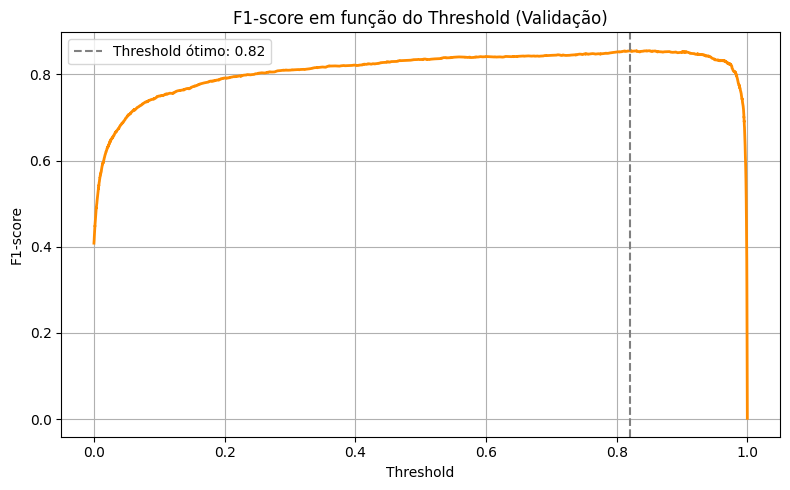

/tmp/ipython-input-263309985.py:83: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




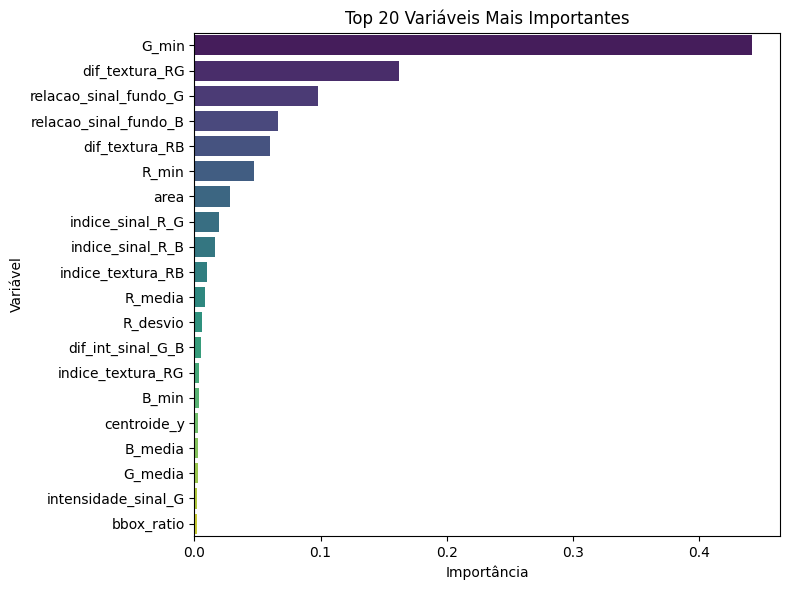

In [39]:
# GradientBoostingClassifier
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, precision_recall_curve, f1_score,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTEENN
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Codificação das classes ===
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# === 2. Balanceamento com SMOTEENN ===
smote_enn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train_encoded)

# === 3. Modelo Gradient Boosting com early stopping ===
gb_model = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.9,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
gb_model.fit(X_train_res, y_train_res)

# === 4. Validação escondida: Previsão probabilística ===
y_proba_val = gb_model.predict_proba(X_val)[:, 1]

# === 5. Ajuste do threshold com base no melhor F1 na validação ===
precision_val, recall_val, thresholds_val = precision_recall_curve(y_val_encoded, y_proba_val)
f1_scores_val = 2 * precision_val * recall_val / (precision_val + recall_val + 1e-6)
best_threshold_val = thresholds_val[np.argmax(f1_scores_val)]

print(f"\n [Validação] Melhor threshold para F1: {best_threshold_val:.3f}")

# === 6. Aplicar threshold na validação ===
y_pred_val_opt = (y_proba_val >= best_threshold_val).astype(int)

# === 7. Relatório da Validação ===
print("\n=== Relatório da Validação com Threshold Otimizado ===")
print(classification_report(y_val_encoded, y_pred_val_opt, target_names=le.classes_))

# === 8. Teste final com o mesmo threshold ===
y_proba_test = gb_model.predict_proba(X_test)[:, 1]
y_pred_test_opt = (y_proba_test >= best_threshold_val).astype(int)

print("\n=== Relatório Final (Teste) com Threshold da Validação ===")
print(classification_report(y_test_encoded, y_pred_test_opt, target_names=le.classes_))

# === 9. AUC-ROC do teste ===
roc_score = roc_auc_score(y_test_encoded, y_proba_test)
print(f"AUC-ROC no Teste: {roc_score:.3f}")

# === 10. Gráfico: F1 x Threshold (Validação) ===
plt.figure(figsize=(8, 5))
plt.plot(thresholds_val, f1_scores_val[:-1], color='darkorange', lw=2) # Slice f1_scores_val
plt.axvline(best_threshold_val, color='gray', linestyle='--', label=f'Threshold ótimo: {best_threshold_val:.2f}')
plt.title("F1-score em função do Threshold (Validação)")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 11. Importância das Variáveis ===
importances = pd.Series(gb_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 20 Variáveis Mais Importantes")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

In [38]:
# === 6. Matriz de Confusão ===
cm = confusion_matrix(y_test_encoded, y_pred_test)
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True,
)
fig_cm.update_layout(title='Matriz de Confusão (Teste)', xaxis_title='Previsto', yaxis_title='Real', width=500, height=400) # Moved width and height to update_layout
fig_cm.show()

# === 7. Curva ROC (Teste) ===
fpr, tpr, _ = roc_curve(y_test_encoded, y_proba_test)
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC={roc_auc:.2f})'))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig_roc.update_layout(title='Curva ROC (Teste)', xaxis_title='Taxa de Falso Positivo', yaxis_title='Taxa de Verdadeiro Positivo', width=500, height=400)
fig_roc.show()